#### Loading libraries

In [1]:
import os
import numpy as np
import pandas as pd
from syto.deconvolution.uxm import load_atlas
from syto.data import LOYFER_CELL_TYPE_MATCH_DICT
from tqdm import tqdm
from collections import defaultdict

#### Config and helpers

In [2]:
path = "/data/dmytro/loyfer2023/beta_values/GSE186458/GSE186458"
files = os.listdir(path)

In [3]:
def filename2ctype(f_name: str) -> str:
    """

    Extract cell types from the file name
    It returns the cell type matching to the cell types written in the region information
    e.g.,) Blood-Monocytes -> Blood-Mono+Macro

    """

    f_name = os.path.basename(f_name)
    file_ctype = "_".join(f_name.split("_")[1:]).split("-Z")[0].strip()
    try:
        return LOYFER_CELL_TYPE_MATCH_DICT[file_ctype]
    except KeyError:
        print(
            f"{f_name} cannot be matched to the 39 cell types. NA is assigned for the cell type"
        )
        # print(f_name, "---->", file_ctype)
        return "NA"

#### Parsing files and extracting atlas-overlaping methylomes

In [4]:
atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [5]:
atlas_adipocytes = atlas[atlas["target"] == "Adipocytes"]

In [6]:
results = defaultdict(lambda: np.array)
for file in tqdm(files):
    full_path = os.path.join(path, file)
    ctype = filename2ctype(file)
    if ctype == "NA":
        continue  # Skip
    content = np.fromfile(full_path, dtype=np.uint8).reshape((-1, 2))
    methylation_values = content[:, 0] / content[:, 1]
    atlas_methylome = []
    for i, row in atlas_adipocytes.iterrows():
        atlas_methylome.extend(methylation_values[row["startCpG"] : row["endCpG"]])
    atlas_methylome = np.array(atlas_methylome)
    results[(file, ctype)] = atlas_methylome

  0%|          | 0/253 [00:00<?, ?it/s]/tmp/ipykernel_2502558/3398775695.py:8: RuntimeWarning: invalid value encountered in divide
  methylation_values = content[:,0]/content[:,1]
  4%|▍         | 11/253 [00:00<00:13, 17.71it/s]

GSM6810035_CNVS-NORM-WBC-110033397-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type
GSM6810045_CNVS-NORM-WBC-110036059-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type
GSM6810044_CNVS-NORM-WBC-110033933-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type


 12%|█▏        | 30/253 [00:02<00:13, 16.53it/s]

GSM6810039_CNVS-NORM-WBC-110033745-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type
GSM6810003_CNVS-NORM-cfDNA-110000263-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type
GSM6810005_CNVS-NORM-cfDNA-110027051-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type


 16%|█▌        | 40/253 [00:02<00:10, 19.63it/s]

...

 93%|█████████▎| 236/253 [00:16<00:01, 14.02it/s]

GSM6810010_CNVS-NORM-cfDNA-110032789-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type
GSM6810025_CNVS-NORM-cfDNA-110036152-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type


 97%|█████████▋| 246/253 [00:17<00:00, 14.20it/s]

GSM6810030_CNVS-NORM-WBC-110029639-WGBS-Rep1.hg38.beta cannot be matched to the 39 cell types. NA is assigned for the cell type


100%|██████████| 253/253 [00:17<00:00, 14.30it/s]


#### Visualizing samples

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import umap  # pip install umap-learn
from collections import Counter


def plot_methylome_reduction(data_dict, method="UMAP"):
    """
    Performs dimensionality reduction and plots the result.

    Parameters:
    - data_dict: {(sample_name, cell_type): np.array([beta_values])}
    - method: str, one of 'PCA', 't-SNE', or 'UMAP' (case-insensitive)
    """

    # 1. Prepare the Data Matrix & Extract Raw Labels
    labels = []
    cell_types_raw = []
    matrix_rows = []

    for (sample, cell_type), values in data_dict.items():
        labels.append(sample)
        cell_types_raw.append(cell_type)
        matrix_rows.append(values)

    X = np.stack(matrix_rows)

    # --- NEW: Count cell types and format labels ---
    # Tally up how many samples belong to each cell type
    cell_counts = Counter(cell_types_raw)

    # Create a new list where each label includes the count (e.g., "Neuron (42)")
    cell_types_formatted = [f"{ct} ({cell_counts[ct]})" for ct in cell_types_raw]

    # 2. Handle NaNs and Scaling
    X_imputed = SimpleImputer(strategy="mean").fit_transform(X)
    X_scaled = StandardScaler().fit_transform(X_imputed)

    # 3. Compute Dimensionality Reduction (Conditionally)
    method_upper = method.upper()

    if method_upper == "PCA":
        print("Computing PCA...")
        res = PCA(n_components=2).fit_transform(X_scaled)
        x_label, y_label = "PC 1", "PC 2"

    elif method_upper in ["T-SNE", "TSNE"]:
        print("Computing t-SNE...")
        perp = min(30, len(labels) - 1)
        res = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(
            X_scaled
        )
        x_label, y_label = "t-SNE 1", "t-SNE 2"

    elif method_upper == "UMAP":
        print("Computing UMAP...")
        res = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(
            X_scaled
        )
        x_label, y_label = "UMAP 1", "UMAP 2"

    else:
        raise ValueError("Invalid method. Please choose 'PCA', 't-SNE', or 'UMAP'.")

    # 4. Create Plotting DataFrame
    plot_df = pd.DataFrame(
        {
            "Dim1": res[:, 0],
            "Dim2": res[:, 1],
            "Cell Type": cell_types_formatted,  # Use the formatted strings here!
        }
    )

    # 5. Visual Styling Setup (Shapes + Colors)
    # Sort the original names alphabetically, THEN apply the formatting
    # so the legend remains in a logical alphabetical order.
    unique_raw = sorted(list(set(cell_types_raw)))
    unique_cells_ordered = [f"{ct} ({cell_counts[ct]})" for ct in unique_raw]

    base_colors = sns.color_palette("tab10", 6)
    base_shapes = ["o", "s", "^", "D", "P", "*", "X"]

    custom_palette = {}
    custom_markers = {}

    for i, cell in enumerate(unique_cells_ordered):
        custom_palette[cell] = base_colors[i % len(base_colors)]
        custom_markers[cell] = base_shapes[(i // len(base_colors)) % len(base_shapes)]

    # 6. Visualization
    fig, ax = plt.subplots(figsize=(12, 10))

    sns.scatterplot(
        data=plot_df,
        x="Dim1",
        y="Dim2",
        hue="Cell Type",
        style="Cell Type",
        palette=custom_palette,
        markers=custom_markers,
        ax=ax,
        s=120,
        edgecolor="black",
        alpha=0.8,
    )

    # Prettify the axes
    ax.set_title(f"{method_upper} of Methylome Profiles", fontsize=20, pad=15)
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

    # Extract legend handles
    handles, labels_list = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    # Create the large figure-level legend at the bottom
    fig.legend(
        handles,
        labels_list,
        loc="lower center",
        # bbox_to_anchor=(0.5, -0.2),
        ncol=6,
        title="Cell Types (Color + Shape)",
        title_fontsize=16,
        fontsize=11,
        frameon=True,
        markerscale=1.5,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)

    # Save using dynamic filename based on method
    filename = f"{method_upper.lower()}_methylome_plot.png"
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()


# Example:
# plot_methylome_reduction(your_dictionary, method='t-SNE')

/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/syto-GStZGe-R-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing PCA...


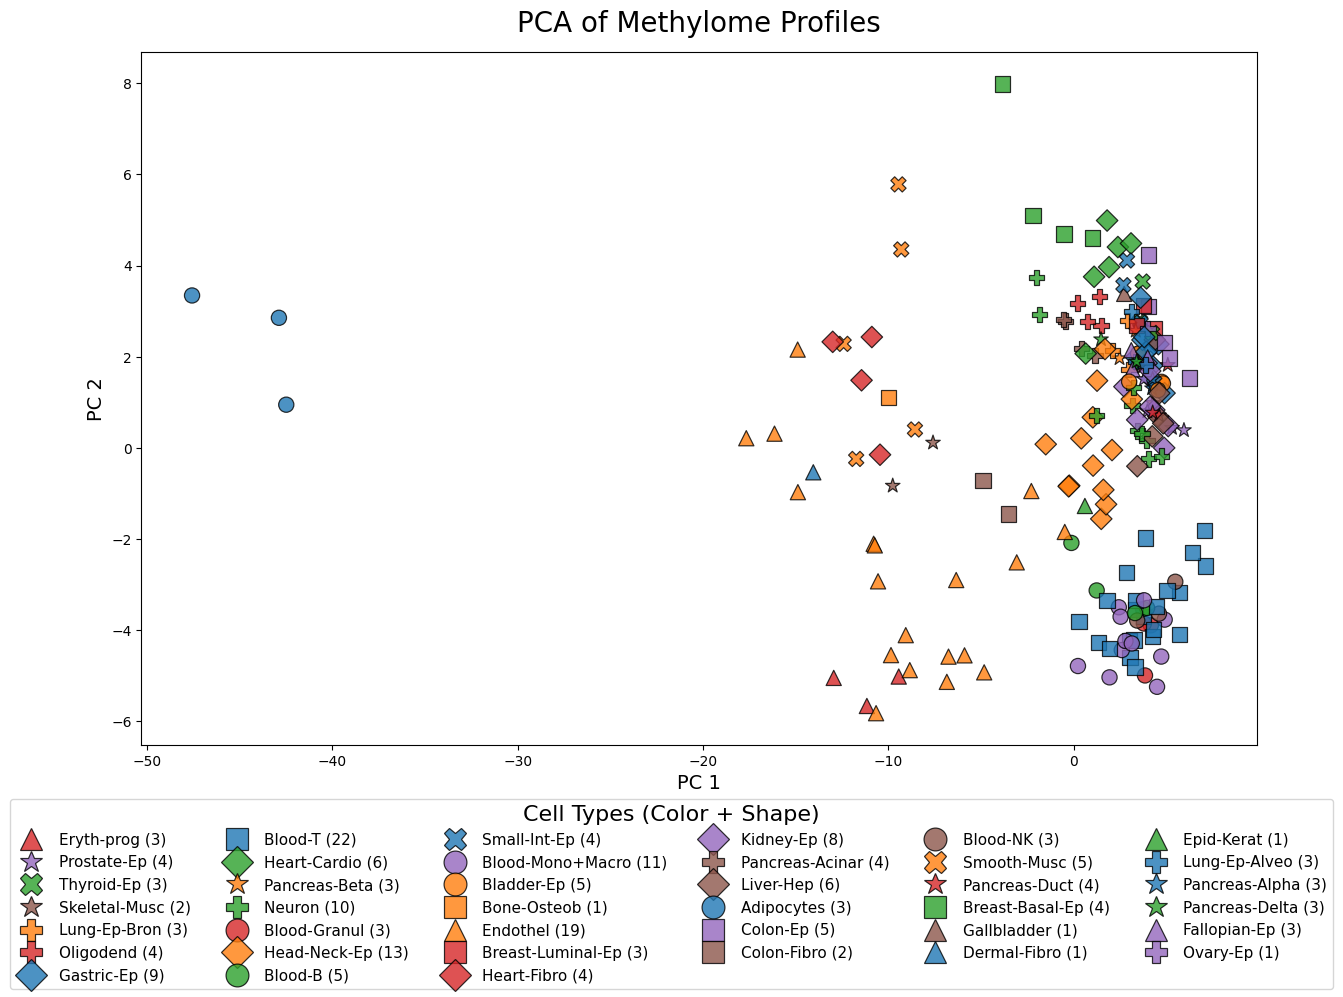

In [8]:
plot_methylome_reduction(results, method="PCA")